In [1]:
from spyplotter import Spectrum, LineIdentifier
from spyplotter.powr import readWRPlot_identfile
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SpectralQuantity, SpectralCoord
%matplotlib widget

# Initialization of a Spectrum

You can either create a spectrum from two arrays directly:

In [2]:
spectrum = Spectrum([1,2,3],[5,6,7])

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


or read it from a *.plot file from a PoWR model:

In [3]:
spectrum_contplines = Spectrum.from_powr(filepath='../tests/test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/wruniq.plot',keywords=['EMERGENT'],dataset=3)

spyplotter.spectrum - INFO - Flux calibrated spectrum at 10 pc. Thus using erg / (Angstrom s cm2) as y unit.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed


Dataset 3 corresponds to the spectrum that contains continuum + lines.




You can also read an observed spectrum from a table file (e.g. csv) with numpy or pandas and then create a Spectrum object:

In [4]:
filename = '../tests/test_data/simulated_spectrum.csv'
data_sim = np.loadtxt(filename, skiprows=1,delimiter=',')
spectrum_sim = Spectrum(data_sim[:,0],data_sim[:,1])

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


or read from a file containing a xy table:

In [5]:
spectrum_sim = Spectrum.from_file(filename,skiprows=1,delimiter=',')

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


# Plot spectrum

When plotting the spectrum, you can choose the flux units and the units for the x-axis by using the common astropy units:

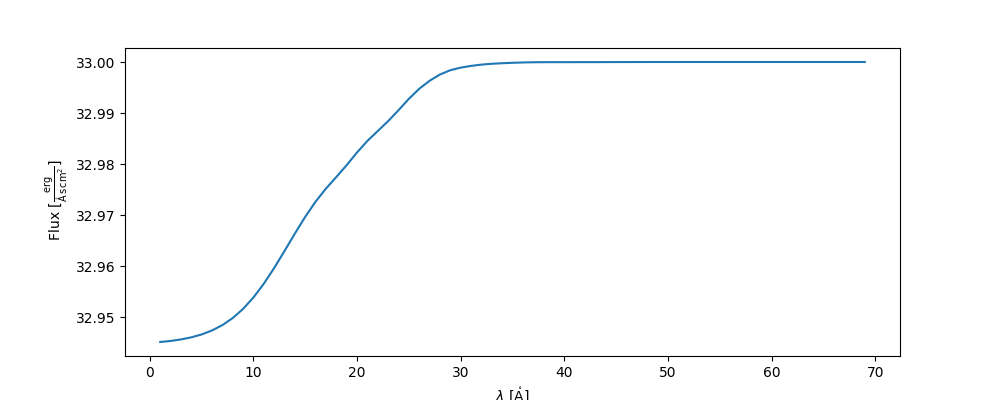

In [6]:
fig = spectrum_contplines.plot(x_unit=u.AA);

You can easily plot another normalized spectrum:

spyplotter.spectrum - INFO - No flux unit specified and no signs for y units detected. Thus assuming normalized spectum.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


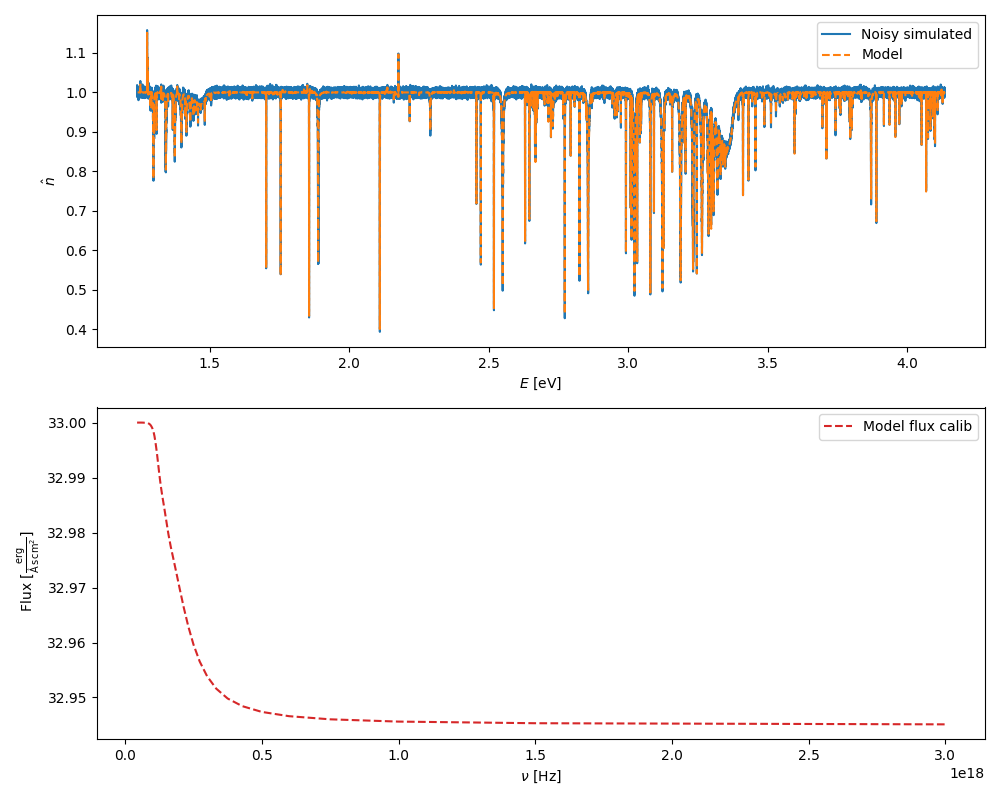

In [7]:
spectrum_norm = Spectrum.from_powr(filepath='../tests/test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/formal.plot',keywords=['OPT'],dataset=1)

fig,ax = plt.subplots(2,1,figsize=(10,8))

spectrum_sim.plot(x_unit=u.eV,ax=ax[0],color='C00',label='Noisy simulated');
spectrum_norm.plot(x_unit=u.eV,ax=ax[0],ls='--',color='C01',label='Model');
spectrum_contplines.plot(x_unit=u.Hz,ax=ax[1],ls='--',color='C03',label='Model flux calib');

for i in range(2):
    ax[i].legend()
plt.tight_layout()

If you want to zoom into specific regions:

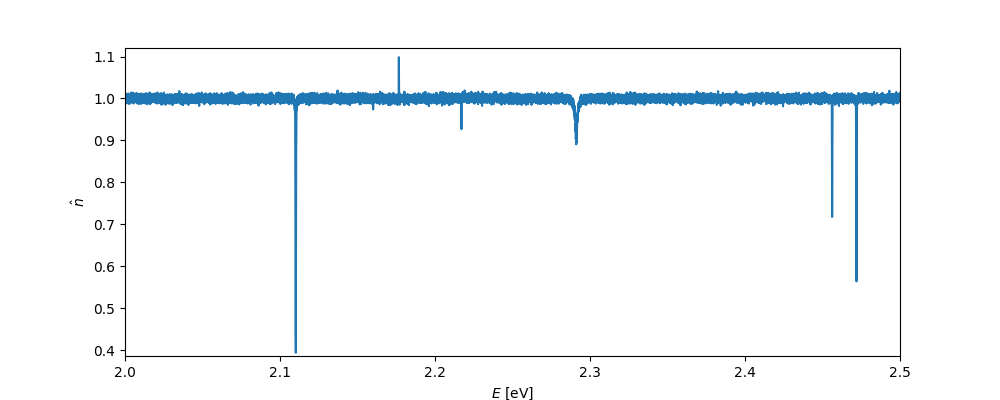

In [8]:
spectrum_sim.plot(x_unit=u.eV,color='C00',label='Noisy simulated',interval=[2,2.5]);

If you want to zoom multiple regions, use zoom_plot and a list of intervals. You can use the helper function generate_intervals to get equally spaced intervals.

[[2.0, 2.25], [2.25, 2.5], [2.5, 2.75], [2.75, 3.0]]


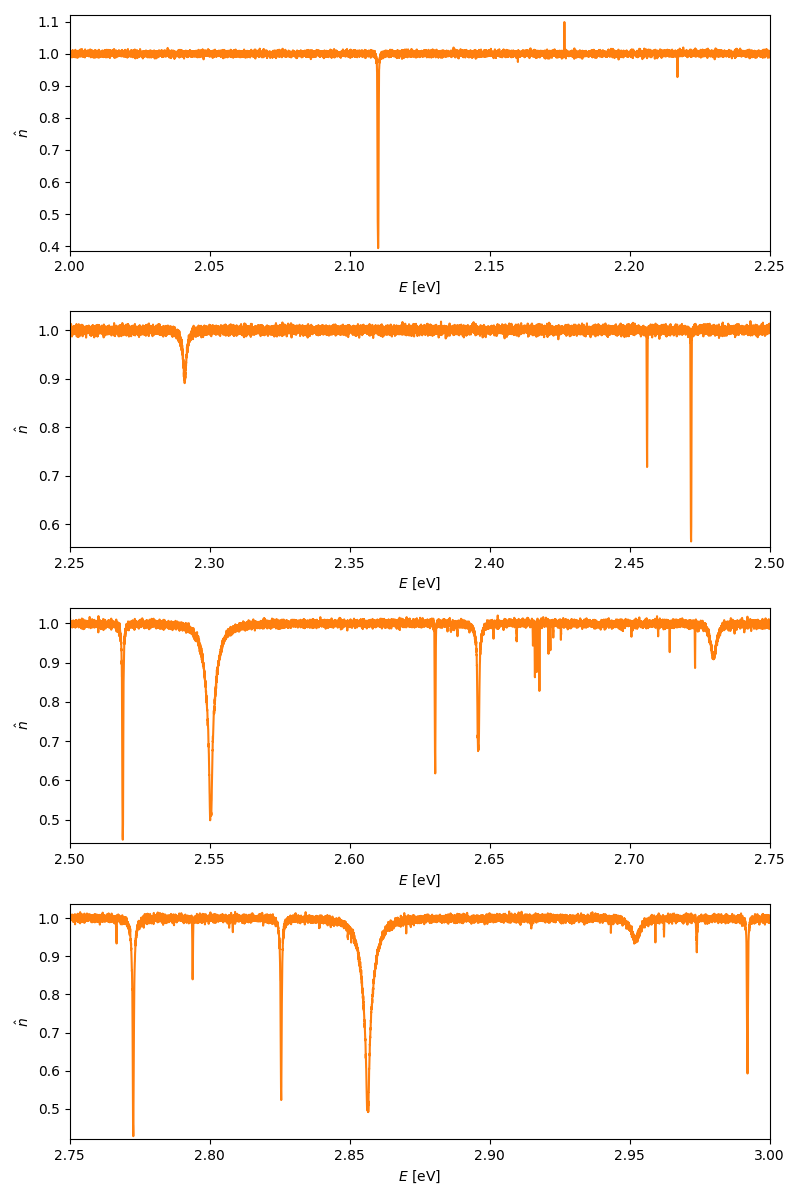

In [9]:
from spyplotter.spec_tools import generate_intervals
intervals = generate_intervals(2,3,4)
print(intervals)

spectrum_sim.zoom_plot(x_unit=u.eV,intervals=intervals,fig_height=3,fig_width=8,color='C01');
plt.tight_layout()

# Convert whole spectrum into other units

In [10]:
spectrum_sim.x_unit

Unit("Angstrom")

In [11]:
spectrum_sim.convert_units(x_unit=u.nm)

In [12]:
spectrum_sim.x_unit

Unit("nm")

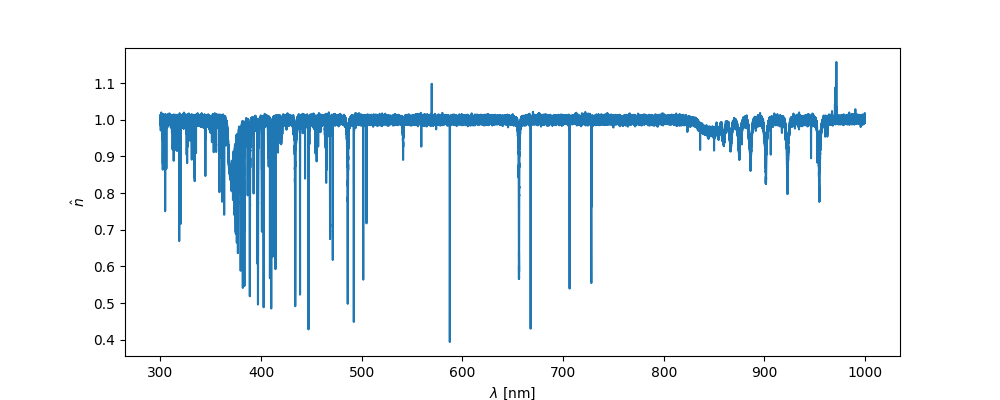

In [13]:
spectrum_sim.plot();

# Apply radial velocity shift

You can hoose if you want to create a new spectrum with an applied spectrum or overwrite the current spectrum.

In the following example, a new spectrum object is created with the same characteristics as before, only that it has a shifted spectrum given by the radial velocity.

spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assuming km/s.
spyplotter.spectrum - INFO - Keeping units of x: nm
spyplotter.spectrum - INFO - Keeping units of y: 


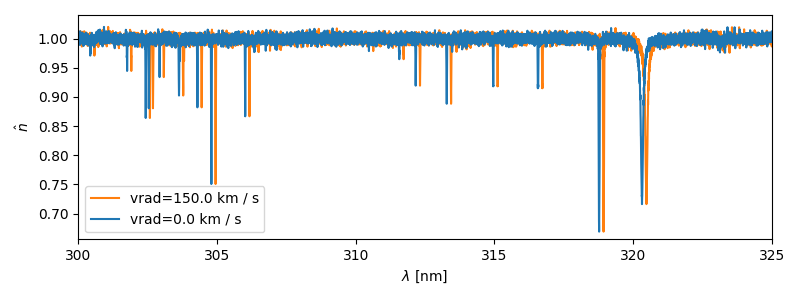

In [14]:
spectrum_shifted=spectrum_sim.apply_shift_vrad(150.,new_spectrum=True)
ax = spectrum_shifted.plot(x_unit=u.nm,interval=[300,325],fig_height=3,fig_width=8,color='C01',label=f'vrad={spectrum_shifted.vrad}');
spectrum_sim.plot(ax=ax,x_unit=u.nm,interval=[300,325],color='C00',label=f'vrad={spectrum_sim.vrad}');
ax.legend()
plt.tight_layout()

# Convert to velocity space

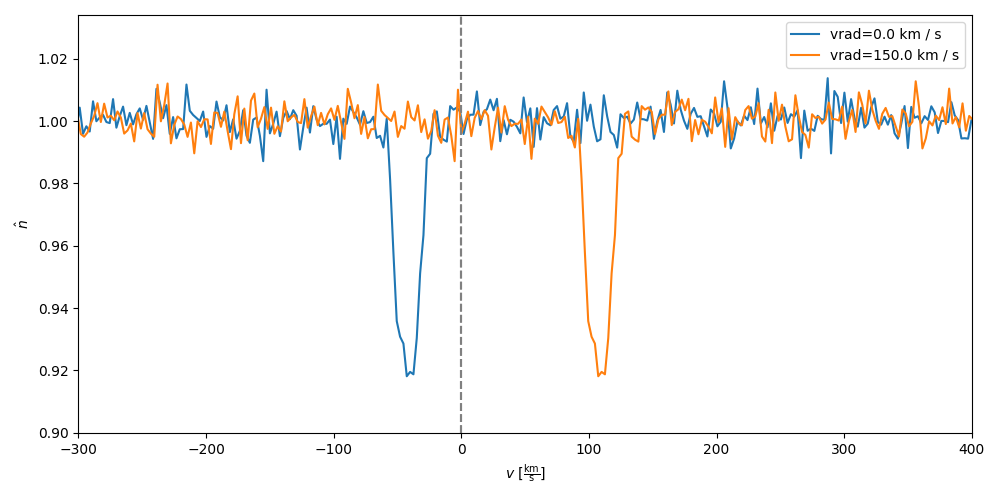

In [15]:
fig, ax = plt.subplots(figsize=(10,5))

#without radial shift
spectrum_sim.plot_velocity(x_rest=315*u.nm,interval=[-300,400],ax=ax,label=f'vrad={spectrum_sim.vrad}');

#with radial shift -> does not change whole spectrum, only for plotting
vrad = 150 * u.km / u.s
spectrum_sim.plot_velocity(x_rest=315*u.nm,vrad=vrad,ax=ax,color='C01',label=f'vrad={vrad}');

ax.legend()
plt.tight_layout()

When specifying an interval for the velocity plot, you can also use units for the interval. You can use velocity but also wavelength, energy or frequency units:



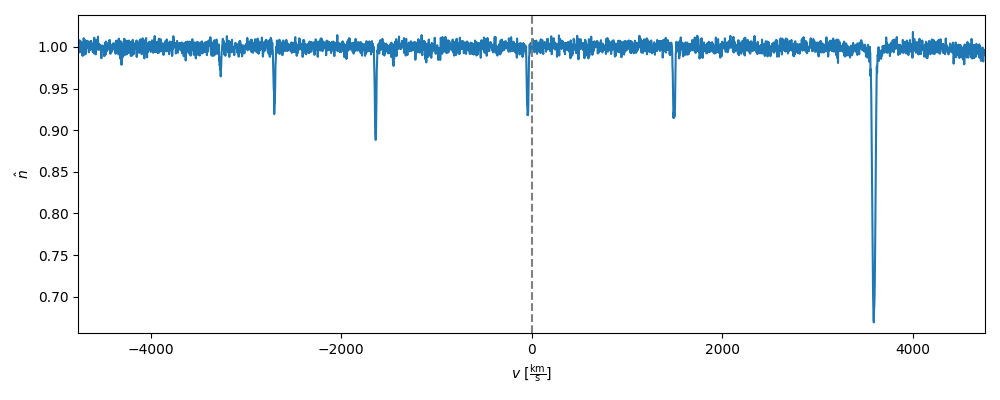

In [16]:
interval_units = [310,320] * u.nm
spectrum_sim.plot_velocity(x_rest=315*u.nm,interval=interval_units,label=f'vrad={spectrum_sim.vrad}');
plt.tight_layout()

# Line Identification

You can easily implement line identification by setting up a Line Identifier. You can also choose the text style for individual lines

In [17]:
line_kwargs = {'color':'red'}
text_kwargs_list =  [{'color':'red','weight':'bold'},{'color':'blue','style':'italic'},{'color':'green'}]

spyplotter.line_identification - WARNING - Text out of ylim, automatically adapting ymax now from ymax_old=1.02 to ymax_new=1.16


{'color': 'red', 'weight': 'bold'}
(0.4837174454, 1.2180000000000002)


/tmp/ipykernel_776406/3188758524.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


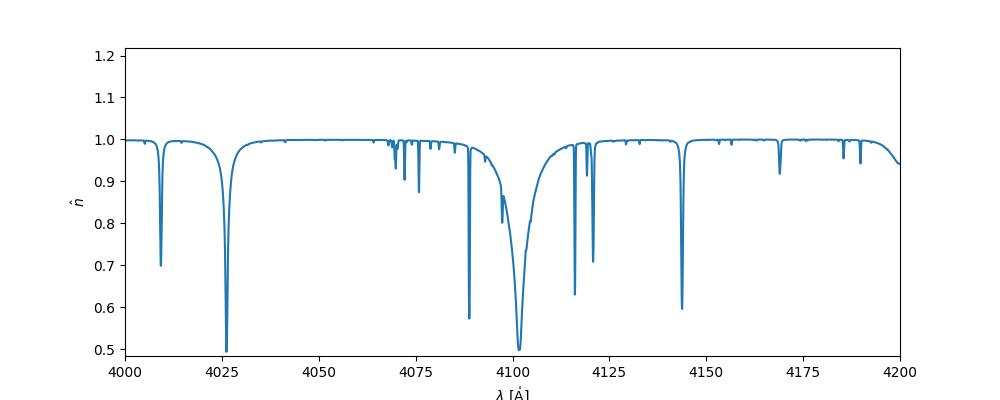

In [19]:
# Plot the spectrum
ax = spectrum_norm.plot(x_unit=u.AA,interval=[4000,4200]);

#for demo purposes randomly chosen numbers and ions
line_info = {'NIII':[302.7,302.8],'CIV':[301.8],'NV':[300.5,301,301.5]}

li = LineIdentifier(line_info,font_dict_list=text_kwargs_list)
print(li.font_dict_list[0])
ax = li.plot(ax=ax,line_kwargs=line_kwargs)

print(ax.get_ylim())
plt.tight_layout()

String formats as in wrplot is supported as well. A given string will be translated into latex format and a dictionary containing the text formatting. 
First, you have to read the ident file and then you can plot. Read the WRPlot Text attributes (p. 27 for the meaning of all prefixes). The lines are here just randomly chosen as example

spyplotter.line_identification - WARNING - Text out of ylim, automatically adapting ymax now from ymax_old=1.02 to ymax_new=1.16


{'O$\\,$II': [4007.462], 'N$\\,$IV': [4057.76], 'Si$\\,$IV': [4116.1], 'N$\\,$III': [4097.35], 'H$\\delta$': [4101.7], 'He$\\,$I': [4120.8, 4143.8, 4168.97], 'He$\\,$II': [4199.9, 4201.0]} [{'fontstretch': 'ultra-condensed'}, {'fontstretch': 'ultra-condensed'}, {'fontstretch': 'ultra-condensed'}, {'fontstretch': 'ultra-condensed'}, {'fontstretch': 'ultra-condensed'}, {'fontstretch': 'ultra-condensed'}, {'fontstretch': 'ultra-condensed'}]
7 7


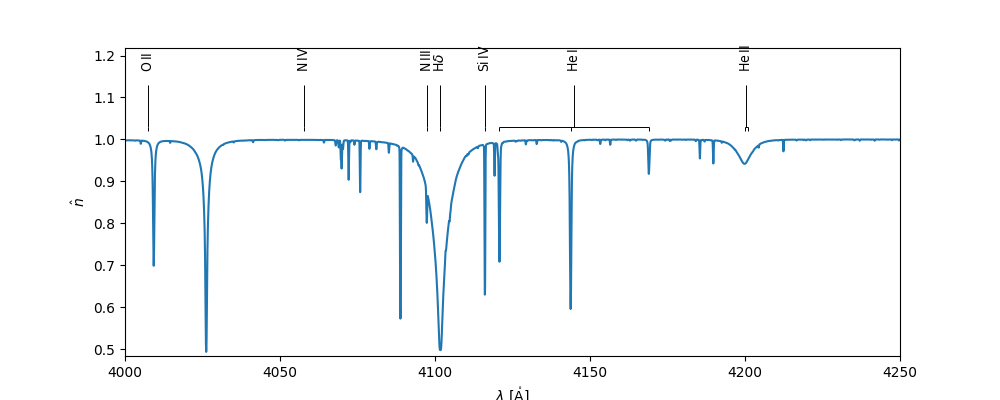

In [20]:
# Plot the spectrum
ax = spectrum_norm.plot(x_unit=u.AA,interval=[4000,4250]);

readWRPlot_identfile(filepath='../tests/test_data/ident_O.dat',keyword='* IDENT BLUE')

li = LineIdentifier.from_powr_identfile('../tests/test_data/ident_O.dat')
ax = li.plot(ax=ax)
#
#print(ax.get_ylim())
#plt.tight_layout()